## Exponential Smoothing Practical

In this practical we will explore a dataset contianing a company's revenue over time and build forecasts using exponential smoothing


### Exercise 1: 

1. Read in `data/MonthlySales.csv`
2. Divide each entry in the revenue column by 1e6 in order to convert to a millions scale
3. Select just the `Period` and `Revenue` columns and save this to a dataframe called `df`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf

In [2]:
# 1. Import the data
# Your code here
full_df = pd.read_csv("data/MonthlySales.csv")

# Here we have monthly sales data for a company.
# We will focus solely on the revenue and explore if we can model the company revenue using time series.

# 2. Convert the revenue to be on a scale of millions for readability.
# Your code here
full_df["Revenue"] = full_df["Revenue"].apply(lambda x: x / 1e6)

# 3. Select a subsection
# Your code here
df = full_df.loc[:, ["Period", "Revenue"]].copy()


Run the below cells to dropnans and format the datetimes

In [3]:
# Drop any NaN values
df.dropna(inplace=True)

# Convert the data to have datetime indices
# df.loc[:,'Period'] = pd.to_datetime(df['Period'], format="%d.%m.%Y")
df["Period"] = pd.to_datetime(df["Period"], format="%d.%m.%Y")
df.set_index("Period", inplace=True)

# For our model building later, we attach a data frequency to the times. This is not essential but avoids warnings
df.index = pd.DatetimeIndex(df.index.values, freq=df.index.inferred_freq)
df.head()

,Revenue
2015-01-01,16.010072
2015-02-01,15.807587
2015-03-01,22.047146
2015-04-01,18.814583
2015-05-01,14.021480


### Exercise 2:

Plot the data and think about features that you see.

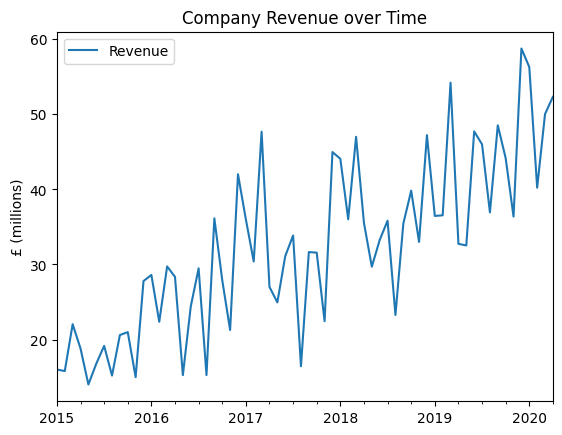

In [4]:
# Your code here
ax = df.plot()
ax.set_ylabel("£ (millions)")
ax.set_title("Company Revenue over Time")
plt.show()


### Exercise 3: 

Split the data into training and test sets, using the last 12 data points as the test set, representing 1 year.

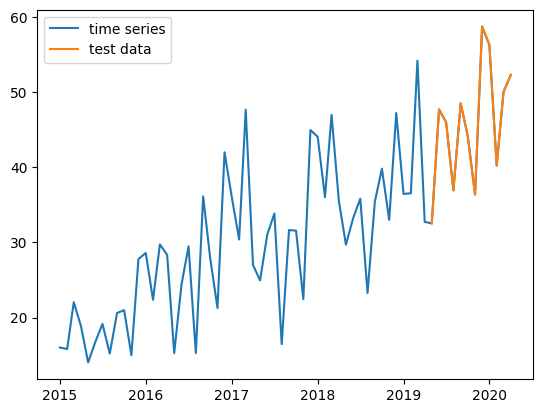

In [5]:
# Your code here
train = df[:-12]
test = df[-12:]

plt.figure()
plt.plot(df)
plt.plot(test)
plt.legend(["time series", "test data"])

### Exercise 4: 

1. Using the function `SimpleExpSmoothing` with `initialization_method="estimated"` to fit the SES model to the training data. Note that when using .fit() with no provided parameters, the function will run an automatic optimization to select the parameter $\alpha$ for us.

2. Then use your model to forecast `len(test)` data points, which is our prediction of the test data, and save the output to `ypred`. The remaining code will plot the result. 

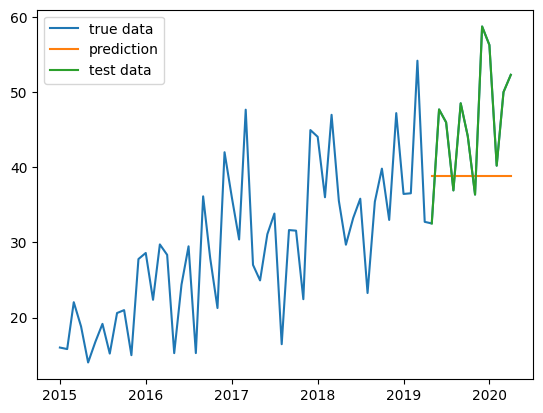

In [6]:
# Your code here
ses_model = SimpleExpSmoothing(train, initialization_method="estimated").fit()
y_pred = ses_model.forecast(len(test))

plt.figure()
plt.plot(df)
plt.plot(test.index, y_pred)
plt.plot(test)
plt.legend(["true data", "prediction", "test data"])

As expected here, we see that the SES model produces a flat forecast based on a weighted average of past values. However, we clearly have a trend component in our data, so let's see if we can improve the forecast. 

Note that you could manually find the trend, difference the data to remove the trend and create a forecast this way, however Holt's Linear Model will essentially do this for us!

### Exercise 5:

Now use the `ExponentialSmoothing` function to create an instance of Holt's linear model (DES). Recall that we can include an additive trend component using `trend="add"`.

As before, create a forecast of length equal to the test data and call this `y_pred`.

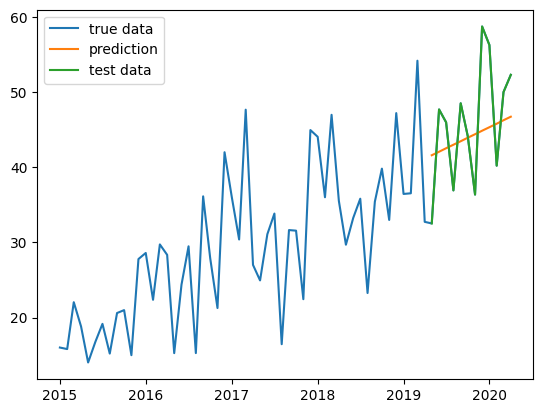

In [7]:
# Your code here
des_model = ExponentialSmoothing(
    train, trend="add", initialization_method="estimated"
).fit()
y_pred = des_model.forecast(len(test))

plt.figure()
plt.plot(df)
plt.plot(test.index, y_pred)
plt.plot(test)
plt.legend(["true data", "prediction", "test data"])

### Exercise 6: 

An extension of Holt's Linear Model to include seasonality is known as Holt Winters. This works in a very similar way, adding in a seasonal component to the forecast equation, and creating a seasonal equation which shows a weighted average between the current seasonal index, and the seasonal index of the same season at the last periodicity. 

This is very simply included in the `ExponentialSmoothing` function by including 2 parameters: `seasonal` and `seasonal_periods`. In order to know what period to use, let's first use the autocorrelation function (ACF). 

Using `plot_acf`, explore the ACF for our data, using lags up to 15. 

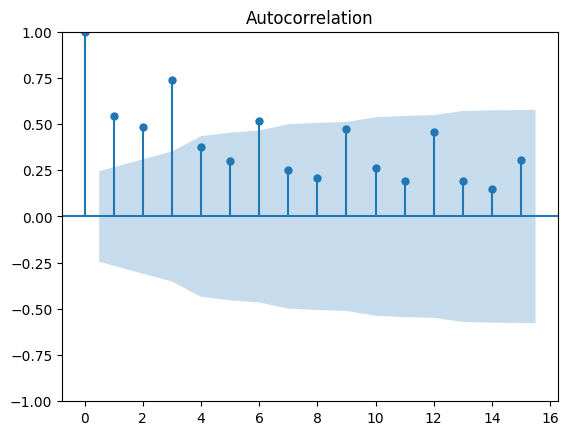

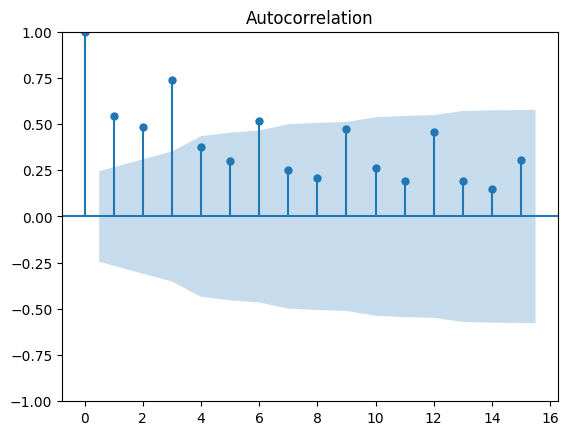

In [8]:
# Your code here
plot_acf(df, lags=15)


### Exercise 7:

Create a Holt Winters forecast using the following steps:

1. Use the `ExponentialSmoothing` function with the training data `train`.
2. Specify `seasonal="add"` and `initialization_method="estimated"`
3. Use the largest significant lag as the value for `seasonal_periods` 
4. Use `.fit()` to fit the model
5. Using `.forecast(len(test))` create a forecast and store it in `y_pred` 

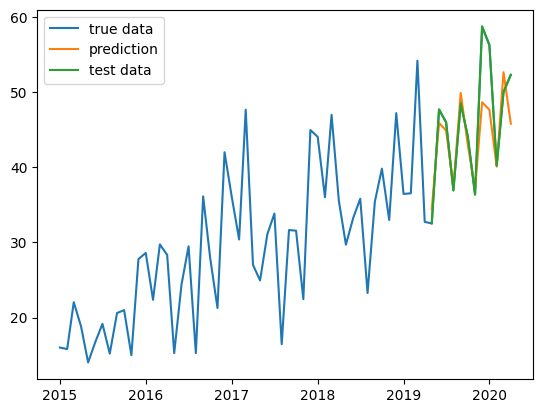

In [9]:
# Your code here
tes_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=6,
    initialization_method="estimated",
).fit()


y_pred = tes_model.forecast(len(test))

plt.figure()
plt.plot(df)
plt.plot(test.index, y_pred)
plt.plot(test)
plt.legend(["true data", "prediction", "test data"])

Note that we could explore the residuals and build out a model for those if we believed there was signal in them. Our forecast would then be the sum of these models.  